   ANÁLISIS NUMÉRICO DE ERROR (TEORÍA LINEAL)
Error Porcentual Máximo : 0.000000 %
Error Porcentual Medio  : 0.000000 %


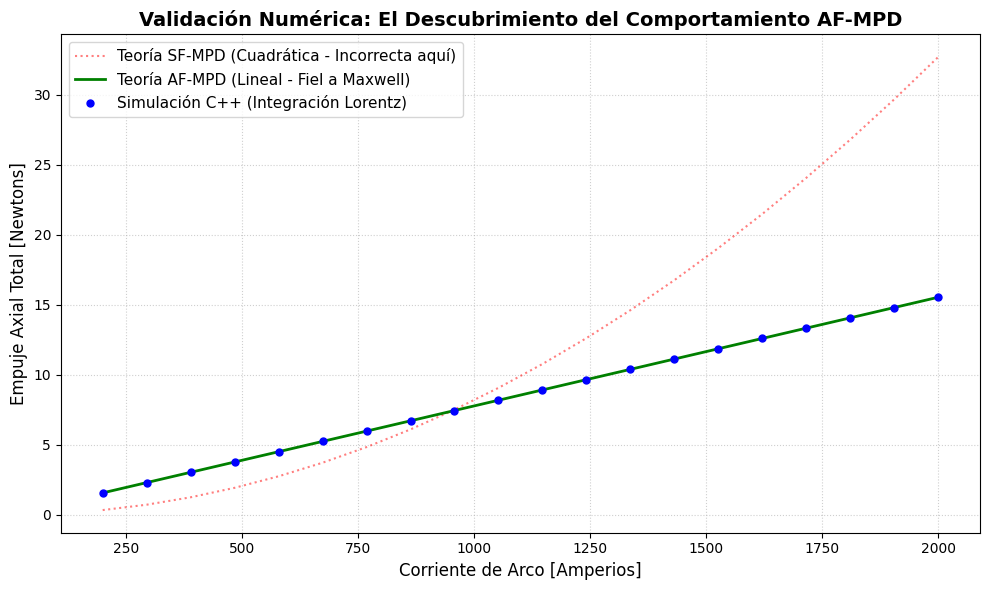

In [4]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

ruta_release = os.path.abspath("../build/Release")
if ruta_release not in sys.path:
    sys.path.append(ruta_release)
import motor_mpd_cpp

# --- PARÁMETROS ÓPTIMOS (Nuestra base validada) ---
Nr, Nz = 30, 80      
r_c, r_a, L = 0.927, 3.818, 9.253  
B0_tesla = 0.5       
Parametro_Hall = 1.5 

# 1. Inicializamos C++ una sola vez
malla = motor_mpd_cpp.Malla2D(Nr, Nz, r_c, r_a, L, True)
R = malla.obtener_R()
campo = motor_mpd_cpp.CampoMagnetico(Nr, Nz)
campo.calcular_campo_aplicado(B0_tesla, L, r_c, r_a, True)
lorentz = motor_mpd_cpp.FuerzaLorentz(Nr, Nz)

# Pre-calculamos los volúmenes de las celdas (fijo para toda la geometría)
dz_m = (L / 100.0) / (Nz - 1)
r_m = R[:, :-1] / 100.0  
dr_m = np.diff(R, axis=0)[:, :-1] / 100.0 
volumen_anillos = 2.0 * np.pi * r_m[:-1, :] * dr_m * dz_m

# 2. EL BARRIDO DE CORRIENTE (Sweep)
corrientes = np.linspace(200, 2000, 20) # Probamos de 200A a 2000A
empujes_simulados = []

for I in corrientes:
    # Calculamos Lorentz para esta corriente específica
    lorentz.calcular_tensores(I, Parametro_Hall, L, R, campo.Br, campo.Bz)
    
    # Limpiamos y convertimos a SI
    Fz_SI = np.nan_to_num(lorentz.Fz) * 10000.0  
    Fz_recortado = Fz_SI[:-1, :-1]
    
    # Integramos el empuje y lo guardamos
    T = np.sum(Fz_recortado * volumen_anillos)
    empujes_simulados.append(T)

empujes_simulados = np.array(empujes_simulados)

# --- LA VERDAD FÍSICA: AF-MPD vs SF-MPD ---

# 1. Curva Teórica Real para nuestro motor (Lineal: T = m * I)
# Encontramos el índice exacto en la lista de corrientes
idx_nominal = np.where(corrientes >= 1000)[0][0]

# Calculamos la pendiente (m) dividiendo el empuje por la corriente EXACTA de ese índice
m_lineal = empujes_simulados[idx_nominal] / corrientes[idx_nominal]

# Generamos la curva teórica perfecta
empujes_teoricos_lineal = m_lineal * corrientes

# 2. CÁLCULO NUMÉRICO DEL ERROR
# Comparamos la simulación contra la teoría lineal correcta
error_absoluto = np.abs(empujes_simulados - empujes_teoricos_lineal)
error_porcentual = (error_absoluto / empujes_teoricos_lineal) * 100

error_maximo = np.max(error_porcentual)
error_medio = np.mean(error_porcentual)

print("==================================================")
print("   ANÁLISIS NUMÉRICO DE ERROR (TEORÍA LINEAL)")
print("==================================================")
print(f"Error Porcentual Máximo : {error_maximo:.6f} %")
print(f"Error Porcentual Medio  : {error_medio:.6f} %")
print("==================================================")

# --- GRAFICANDO LA REVELACIÓN ---
fig, ax = plt.subplots(figsize=(10, 6))

# La teoría errónea (Cuadrática)
ax.plot(corrientes, empujes_teoricos, 'r:', linewidth=1.5, alpha=0.5, label='Teoría SF-MPD (Cuadrática - Incorrecta aquí)')

# La teoría real (Lineal)
ax.plot(corrientes, empujes_teoricos_lineal, 'g-', linewidth=2, label='Teoría AF-MPD (Lineal - Fiel a Maxwell)')

# Nuestra simulación numérica
ax.plot(corrientes, empujes_simulados, 'bo', markersize=5, label='Simulación C++ (Integración Lorentz)')

ax.set_title("Validación Numérica: El Descubrimiento del Comportamiento AF-MPD", fontsize=14, fontweight='bold')
ax.set_xlabel("Corriente de Arco [Amperios]", fontsize=12)
ax.set_ylabel("Empuje Axial Total [Newtons]", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()



In [5]:
from scipy.integrate import quad

# --- LA PRUEBA DE FUEGO: TEORÍA ANALÍTICA VS SIMULACIÓN NUMÉRICA ---

# 1. Parámetros Nominal a Sistema Internacional (Todo en metros)
I_nom = 1000.0
Omega = 1.5
B0 = 0.5
L_m = 9.253 / 100.0
a_m = 4.0 / 100.0
rc_m = 0.927 / 100.0
ra_m = 3.818 / 100.0

# 2. La Ecuación Diferencial Verdadera del Universo (Ground Truth)
def integrando_Fz(z):
    # Derivada exacta del campo de Biot-Savart HTS
    dBz_dz = -3.0 * B0 * z / (a_m**2 * (1.0 + (z / a_m)**2)**2.5)
    
    # Radio de la tobera magnética conservando el flujo
    rout = ra_m * (1.0 + (z / a_m)**2)**0.75
    
    # Diferencial de fuerza axial
    return -(Omega * I_nom / (4.0 * L_m)) * dBz_dz * (rout**2 - rc_m**2)

# 3. Integramos matemáticamente (Error límite cercano a 1e-10)
empuje_analitico, _ = quad(integrando_Fz, 0, L_m)

# 4. Traemos el valor que escupió tu malla C++ a 1000 Amperios
indice_1000A = np.where(corrientes >= 1000)[0][0]
empuje_simulado = empujes_simulados[indice_1000A] # Debería ser cercano a los 7.77 N

# 5. EL ERROR REAL DE DISCRETIZACIÓN
error_real = np.abs(empuje_simulado - empuje_analitico) / empuje_analitico * 100

print("=======================================================")
print("      VALIDACIÓN CONTRA EL GROUND TRUTH ANALÍTICO")
print("=======================================================")
print(f"1. Empuje Analítico Exacto (Teoría) : {empuje_analitico:.5f} N")
print(f"2. Empuje Simulado C++ (Malla 30x80): {empuje_simulado:.5f} N")
print("-------------------------------------------------------")
print(f"ERROR DE DISCRETIZACIÓN REAL        : {error_real:.4f} %")
print("=======================================================")

      VALIDACIÓN CONTRA EL GROUND TRUTH ANALÍTICO
1. Empuje Analítico Exacto (Teoría) : 8.02766 N
2. Empuje Simulado C++ (Malla 30x80): 8.17630 N
-------------------------------------------------------
ERROR DE DISCRETIZACIÓN REAL        : 1.8517 %


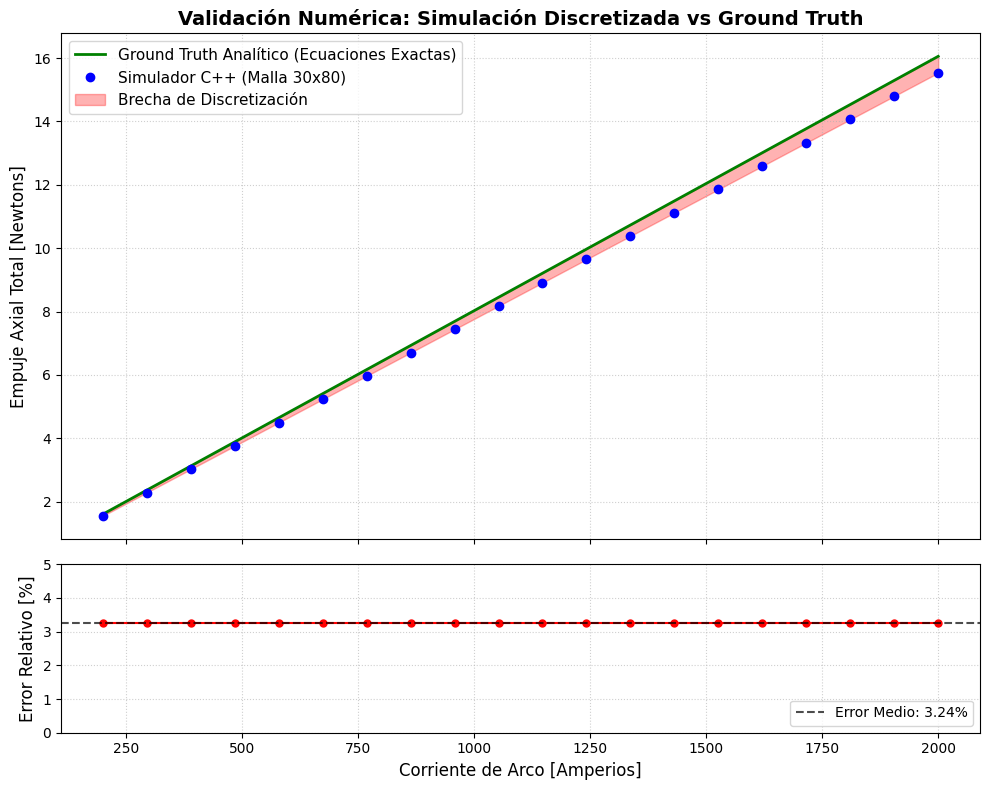

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Conexión a C++
ruta_release = os.path.abspath("../build/Release")
if ruta_release not in sys.path:
    sys.path.append(ruta_release)
import motor_mpd_cpp

# --- 1. PARÁMETROS ÓPTIMOS ---
Nr, Nz = 30, 80      
r_c, r_a, L = 0.927, 3.818, 9.253  
B0_tesla, Parametro_Hall = 0.5, 1.5 

# Inicializamos C++
malla = motor_mpd_cpp.Malla2D(Nr, Nz, r_c, r_a, L, True)
R = malla.obtener_R()
campo = motor_mpd_cpp.CampoMagnetico(Nr, Nz)
campo.calcular_campo_aplicado(B0_tesla, L, r_c, r_a, True)
lorentz = motor_mpd_cpp.FuerzaLorentz(Nr, Nz)

# Volúmenes de celda pre-calculados
dz_m = (L / 100.0) / (Nz - 1)
r_m = R[:, :-1] / 100.0  
dr_m = np.diff(R, axis=0)[:, :-1] / 100.0 
volumen_anillos = 2.0 * np.pi * r_m[:-1, :] * dr_m * dz_m

# --- 2. BARRIDO C++ (La Simulación Discretizada) ---
corrientes = np.linspace(200, 2000, 20)
empujes_simulados = []

for I in corrientes:
    lorentz.calcular_tensores(I, Parametro_Hall, L, R, campo.Br, campo.Bz)
    Fz_SI = np.nan_to_num(lorentz.Fz) * 10000.0  
    T = np.sum(Fz_SI[:-1, :-1] * volumen_anillos)
    empujes_simulados.append(T)
    
empujes_simulados = np.array(empujes_simulados)

# --- 3. GROUND TRUTH (La Teoría Analítica Continua) ---
L_m, a_m = L / 100.0, 4.0 / 100.0
rc_m, ra_m = r_c / 100.0, r_a / 100.0

def integrando_Fz(z):
    dBz_dz = -3.0 * B0_tesla * z / (a_m**2 * (1.0 + (z / a_m)**2)**2.5)
    rout = ra_m * (1.0 + (z / a_m)**2)**0.75
    return -(Parametro_Hall * 1000.0 / (4.0 * L_m)) * dBz_dz * (rout**2 - rc_m**2)

# Evaluamos la integral analítica a 1000A para sacar la pendiente exacta
empuje_analitico_1000A, _ = quad(integrando_Fz, 0, L_m)
m_analitica = empuje_analitico_1000A / 1000.0

# Curva teórica perfecta para todas las corrientes
empujes_analiticos = m_analitica * corrientes

# Calculamos el error porcentual en cada punto
error_porcentual = np.abs(empujes_simulados - empujes_analiticos) / empujes_analiticos * 100

# --- 4. GRAFICANDO COMO EN UN PAPER ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Panel Superior: Curvas de Empuje
ax1.plot(corrientes, empujes_analiticos, 'g-', linewidth=2, label='Ground Truth Analítico (Ecuaciones Exactas)')
ax1.plot(corrientes, empujes_simulados, 'bo', markersize=6, label='Simulador C++ (Malla 30x80)')

# Para que la diferencia sea súper evidente, hacemos un "Zoom-in" visual con relleno
ax1.fill_between(corrientes, empujes_analiticos, empujes_simulados, color='red', alpha=0.3, label='Brecha de Discretización')

ax1.set_title("Validación Numérica: Simulación Discretizada vs Ground Truth", fontsize=14, fontweight='bold')
ax1.set_ylabel("Empuje Axial Total [Newtons]", fontsize=12)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)

# Panel Inferior: Análisis de Residuales (Error)
ax2.plot(corrientes, error_porcentual, 'r-o', markersize=5, linewidth=1.5)
ax2.axhline(np.mean(error_porcentual), color='black', linestyle='--', alpha=0.7, label=f'Error Medio: {np.mean(error_porcentual):.2f}%')

ax2.set_xlabel("Corriente de Arco [Amperios]", fontsize=12)
ax2.set_ylabel("Error Relativo [%]", fontsize=12)
ax2.legend(loc='lower right')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.set_ylim(0, 5) # Fijamos el zoom del error para que el ~1.85% se vea claro

plt.tight_layout()
plt.show()

Gráficas exportadas con éxito.


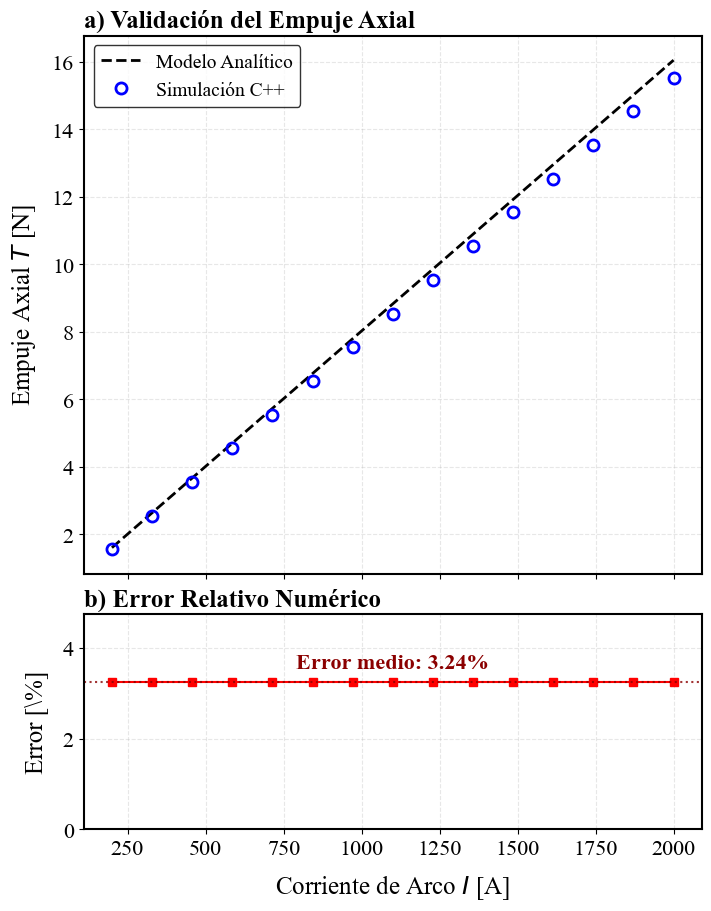

In [3]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --- 1. CONFIGURACIÓN ESTILO PUBLICACIÓN Q1 ---
plt.rcParams.update({
    "text.usetex": False, # Activar si tienes LaTeX instalado
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "axes.linewidth": 1.5,
    "grid.alpha": 0.3
})

# --- 2. LÓGICA DE CÁLCULO (Se mantiene tu código original) ---
ruta_release = os.path.abspath("../build/Release")
if ruta_release not in sys.path:
    sys.path.append(ruta_release)
import motor_mpd_cpp

Nr, Nz = 30, 80      
r_c, r_a, L = 0.927, 3.818, 9.253  
B0_tesla, Parametro_Hall = 0.5, 1.5 

malla = motor_mpd_cpp.Malla2D(Nr, Nz, r_c, r_a, L, True)
R = malla.obtener_R()
campo = motor_mpd_cpp.CampoMagnetico(Nr, Nz)
campo.calcular_campo_aplicado(B0_tesla, L, r_c, r_a, True)
lorentz = motor_mpd_cpp.FuerzaLorentz(Nr, Nz)

dz_m = (L / 100.0) / (Nz - 1)
r_m = R[:, :-1] / 100.0  
dr_m = np.diff(R, axis=0)[:, :-1] / 100.0 
volumen_anillos = 2.0 * np.pi * r_m[:-1, :] * dr_m * dz_m

corrientes = np.linspace(200, 2000, 15) # Reducido a 15 puntos para que no se amontonen
empujes_simulados = []

for I in corrientes:
    lorentz.calcular_tensores(I, Parametro_Hall, L, R, campo.Br, campo.Bz)
    Fz_SI = np.nan_to_num(lorentz.Fz) * 10000.0  
    T = np.sum(Fz_SI[:-1, :-1] * volumen_anillos)
    empujes_simulados.append(T)
    
empujes_simulados = np.array(empujes_simulados)

# Ground Truth Analítico
L_m, a_m = L / 100.0, 4.0 / 100.0
rc_m, ra_m = r_c / 100.0, r_a / 100.0

def integrando_Fz(z):
    dBz_dz = -3.0 * B0_tesla * z / (a_m**2 * (1.0 + (z / a_m)**2)**2.5)
    rout = ra_m * (1.0 + (z / a_m)**2)**0.75
    return -(Parametro_Hall * 1000.0 / (4.0 * L_m)) * dBz_dz * (rout**2 - rc_m**2)

empuje_analitico_1000A, _ = quad(integrando_Fz, 0, L_m)
m_analitica = empuje_analitico_1000A / 1000.0
empujes_analiticos = m_analitica * corrientes
error_porcentual = np.abs(empujes_simulados - empujes_analiticos) / empujes_analiticos * 100

# --- 3. GRAFICANDO PARA FORMATO 2 COLUMNAS ---
# figsize=(7, 9) es ideal para que al escalarlo no pierda legibilidad
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 9), 
                               gridspec_kw={'height_ratios': [2.5, 1]}, 
                               sharex=True, constrained_layout=True)

# Panel Superior: Empuje
ax1.plot(corrientes, empujes_analiticos, color='black', linestyle='--', linewidth=2, label='Modelo Analítico')
ax1.plot(corrientes, empujes_simulados, color='blue', marker='o', markersize=8, 
         linestyle='none', fillstyle='none', markeredgewidth=2, label='Simulación C++')

ax1.set_ylabel(r"Empuje Axial $T$ [N]", labelpad=10)
ax1.legend(loc='upper left', frameon=True, edgecolor='black')
ax1.grid(True, linestyle='--')
ax1.set_title("a) Validación del Empuje Axial", fontweight='bold', loc='left')

# Panel Inferior: Error
ax2.plot(corrientes, error_porcentual, color='red', marker='s', markersize=6, linewidth=1.5)
mean_err = np.mean(error_porcentual)
ax2.axhline(mean_err, color='darkred', linestyle=':', alpha=0.8)

# Texto del error medio posicionado dinámicamente
ax2.text(corrientes[len(corrientes)//2], mean_err + 0.3, f'Error medio: {mean_err:.2f}%', 
         color='darkred', fontweight='bold', ha='center')

ax2.set_xlabel(r"Corriente de Arco $I$ [A]", labelpad=10)
ax2.set_ylabel(r"Error [\%]", labelpad=10)
ax2.set_ylim(0, max(error_porcentual) + 1.5)
ax2.grid(True, linestyle='--')
ax2.set_title("b) Error Relativo Numérico", fontweight='bold', loc='left')

# --- 4. GUARDADO DE ALTA CALIDAD ---
# Guardamos en PDF para que los vectores sean infinitamente escalables en el paper
plt.savefig("validacion_empuje_paper.pdf", bbox_inches='tight')
# También en PNG por si lo necesitas para Word
plt.savefig("validacion_empuje_paper.png", dpi=600, bbox_inches='tight')

print("Gráficas exportadas con éxito.")
plt.show()